Nome:Gabriela Morales Soto

RA:299213

Curso:IA901A



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais: 
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação. 

In [29]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from skimage.transform import resize

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook. 

In [3]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [46]:
def read_image_url(url:str) -> np.ndarray:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

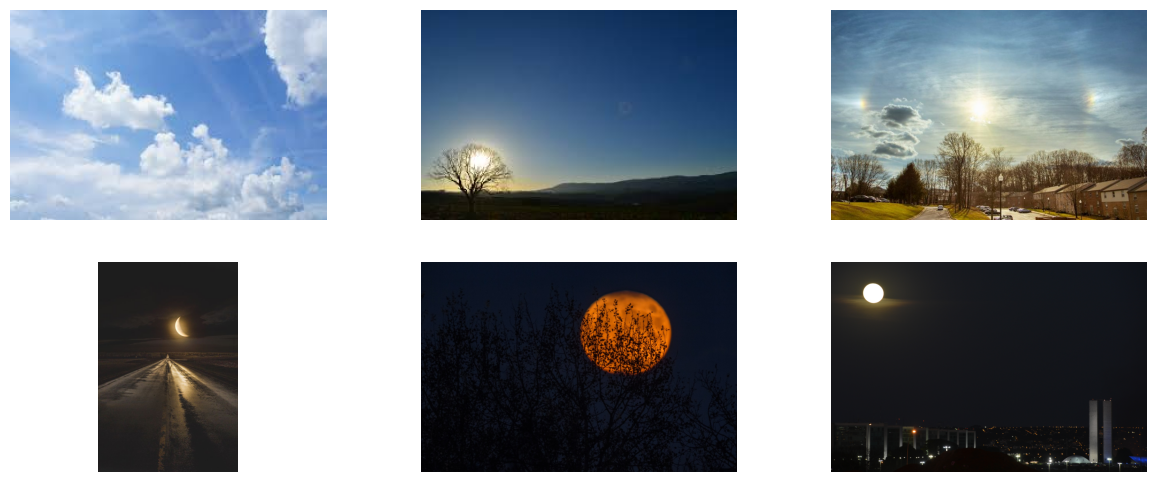

In [47]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:
  
  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))    
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

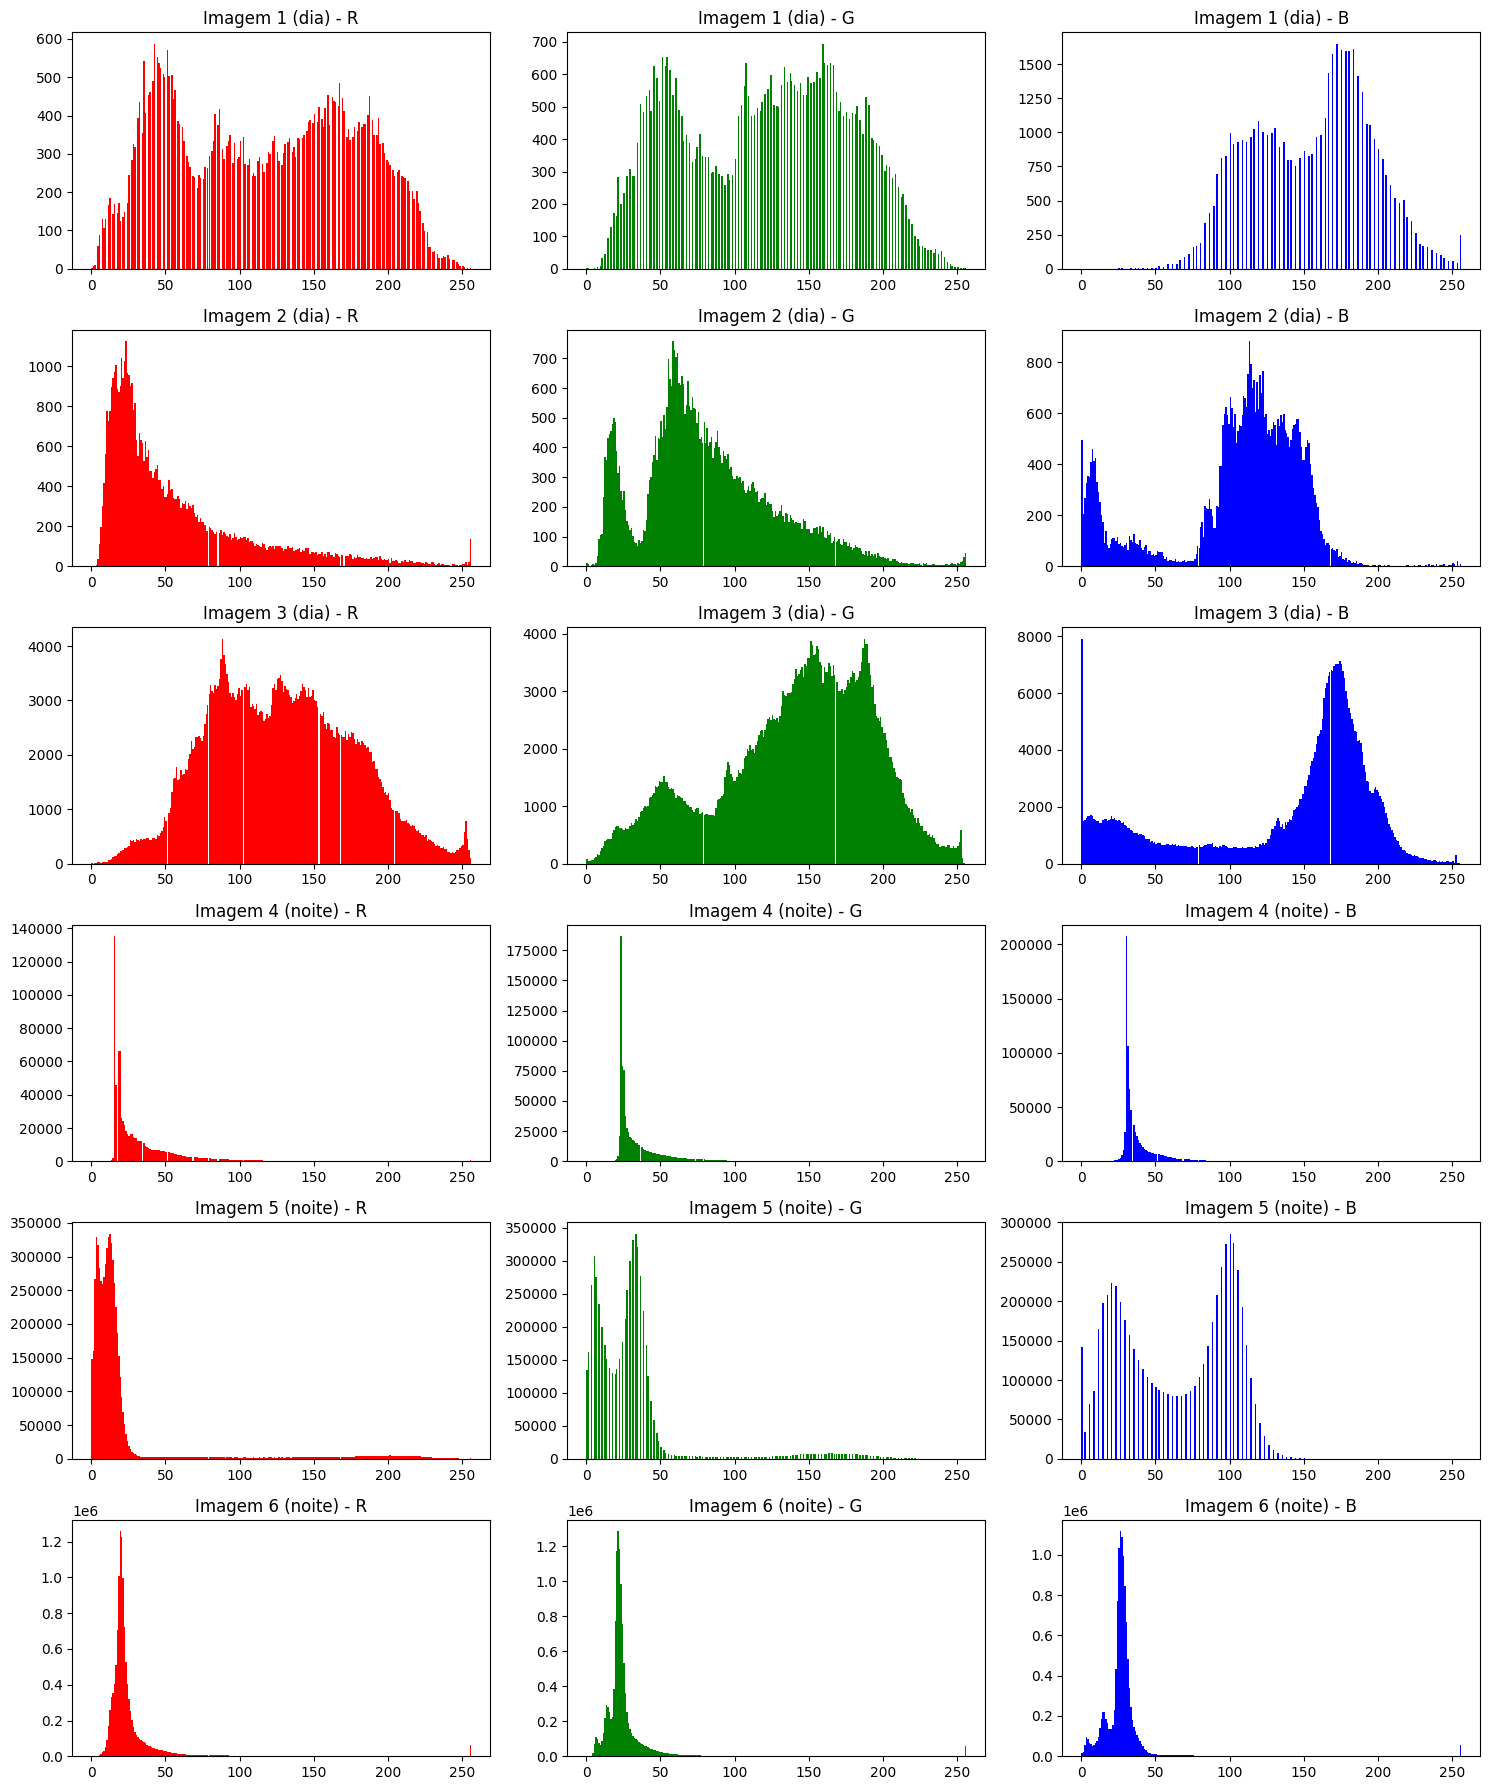

In [48]:
fig, axs = plt.subplots(6, 3, figsize=(15, 18)) 
colors = ['r', 'g', 'b'] 
channel_names = ['R', 'G', 'B']

for i, img in enumerate(all_imgs):
    for j, channel in enumerate(range(3)):
        hist = np.histogram(img[:, :, channel], bins=256)[0]
        plt.subplot(6, 3, i*3 + j + 1)
        plota_hist(hist, colors[j], 256, np.arange(257))
        plt.title(f"Imagem {i+1} ({'dia' if i < 3 else 'noite'}) - {channel_names[j]}")

plt.tight_layout()
plt.show()

Sim, seria  provável acertar a quais classes cada histograma pertence , A razão para isso é que o histograma é uma representação direta da luminosidade global da imagem.Durante a noite, há uma ausência natural de luz. Consequentemente, a câmera captura muito pouca luminosidade, fazendo com que a grande maioria dos pixels tenha valores próximos a zero Durante o dia, a luz solar abundante e suas reflexões nos objetos geram uma ampla gama de tons, desde sombras até áreas muito brilhantes. Isso obriga o histograma a se "esticar" por toda a escala de 0 a 255

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

C:\Users\Gab\AppData\Local\Temp\ipykernel_11876\3644913451.py:27: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


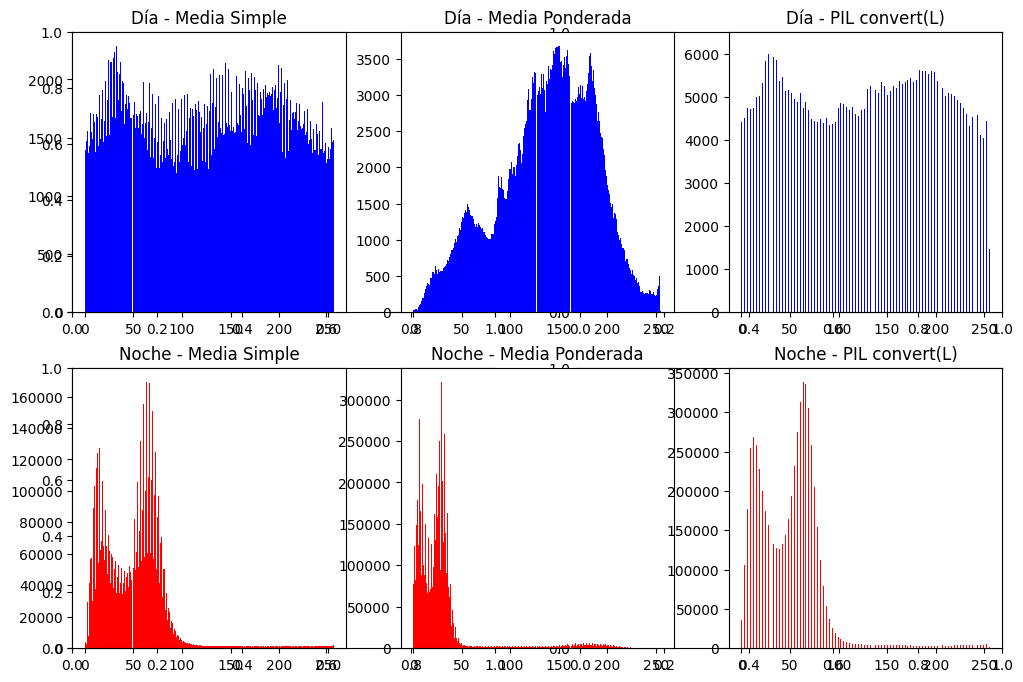

In [7]:
imag_day = all_imgs[2]
imag_night = all_imgs[4]
gray_day = (imag_day[:,:,0]+imag_day[:,:,1]+imag_day[:,:,2])/3
gray_night = (imag_night[:,:,0]+imag_night[:,:,1]+imag_night[:,:,2])/3
gray_pond_day = 0.299*imag_day[:,:,0]+0.587*imag_day[:,:,1]+0.114*imag_day[:,:,2]
gray_pond_night = 0.299*imag_night[:,:,0]+0.587*imag_night[:,:,1]+0.114*imag_night[:,:,2]
pil_dia= np.array(Image.fromarray(gray_day.astype('uint8')).convert('L'))
pil_noite= np.array(Image.fromarray(gray_night.astype('uint8')).convert('L'))
#Histograma
fig,axs = plt.subplots(2,2,figsize=(12, 8))
grays_dia = [gray_day, gray_pond_day, pil_dia]
grays_noite = [gray_night, gray_pond_night, pil_noite]
titles = ['Media Simple', 'Media Ponderada', 'PIL convert(L)']
for i, (gray_d, gray_n, title) in enumerate(zip(grays_dia, grays_noite, titles)):
    # Histograma para día
    plt.subplot(2, 3, i+1)
    hist_d = np.histogram(gray_d.flatten(), bins=256)[0]
    plota_hist(hist_d, 'b', 256, np.arange(257))
    plt.title(f'Día - {title}')
    
    # Histograma para noche
    plt.subplot(2, 3, i+4)
    hist_n = np.histogram(gray_n.flatten(), bins=256)[0]
    plota_hist(hist_n, 'r', 256, np.arange(257))
    plt.title(f'Noche - {title}')

plt.tight_layout()
plt.show()


A distribuição de pixels (Dia) continua ocupando toda a extensão do eixo horizontal (de 0 a 255). Isso confirma que a imagem possui uma ampla gama de luminosidade, contendo desde sombras até áreas muito claras. 
Imagens de Noite, Os histogramas continuam severamente comprimidos no lado esquerdo do gráfico (valores entre 0 e aproximadamente 100).

## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens. 

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [8]:
def histstat(f):
    
    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [9]:
f = all_imgs[0]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

175.75
1035.83
-0.03
-1.11
118.00
132.00
178.00
218.00
237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [10]:
f = all_imgs[3]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')# Seu código aqui

43.47
704.20
3.65
16.82
28.00
29.00
33.00
69.00
179.00


## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors) 

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN: 

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

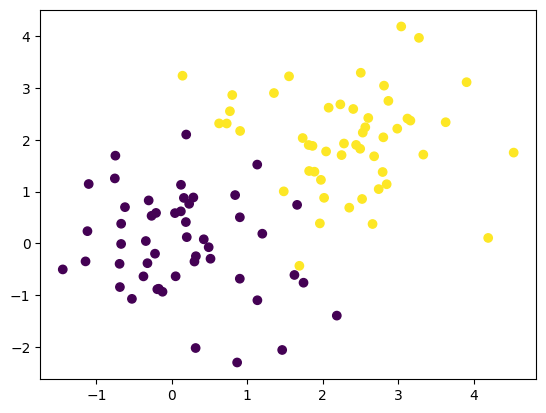

In [11]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y);

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las. 

A função *predict()* é utilizada para classificar as novas amostras.



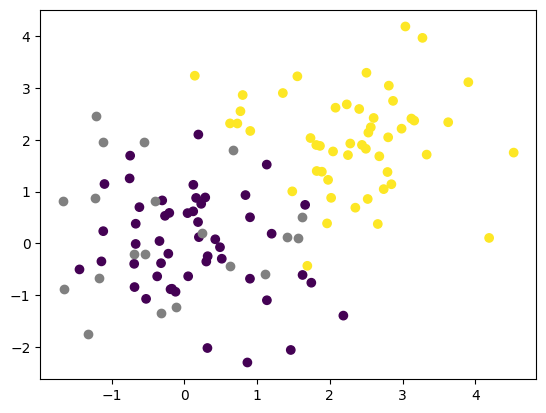

In [12]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [13]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
Precisão: 0.94
Recall: 0.98
F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


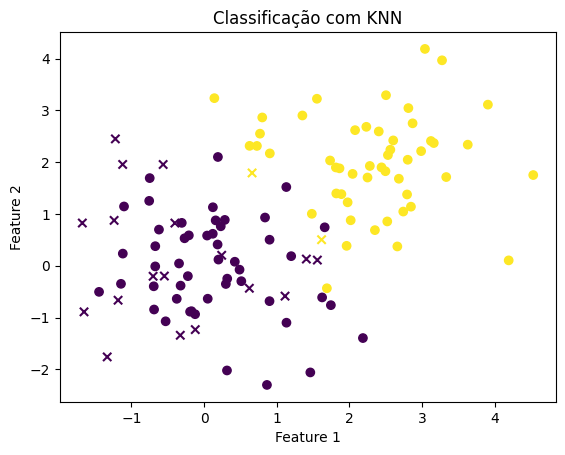

In [14]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [15]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


In [16]:
train_dataset = DermaMNIST(
    split="train",
    download=True 
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

In [17]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []
    
    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

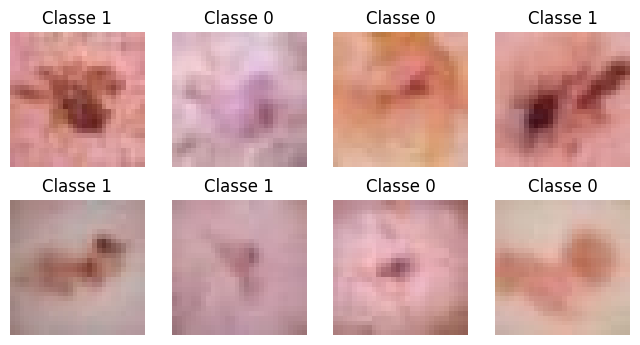

In [18]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
  plt.subplot(2,n_imgs,n+1)
  plt.axis('off')
  tmp = random.randint(0,199)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

  plt.subplot(2,n_imgs,n+n_imgs+1)
  plt.axis('off')
  tmp = random.randint(200,399)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features). 

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9. 

In [19]:
def extract_features(images: list[np.ndarray]) -> np.ndarray:
    features = []
    for img in images:
        gray_img = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])
        hist_features = histstat(gray_img)
        features.append(hist_features)
    return np.array(features)
train_features = extract_features(images_train)
test_features = extract_features(images_test)
print(f'train shape: {train_features.shape}')
print(f'test shape: {test_features.shape}')

train shape: (400, 9)
test shape: (100, 9)


**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


In [26]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(train_features, labels_train)
test_predictions = model.predict(test_features)
train_predictions = model.predict(train_features)
#test
acc_test = accuracy_score(labels_test, test_predictions)
prec_test = precision_score(labels_test, test_predictions)
rec_test = recall_score(labels_test, test_predictions)
f1_test = f1_score(labels_test, test_predictions)
#train
acc_train = accuracy_score(labels_train, train_predictions)
prec_train = precision_score(labels_train, train_predictions)
rec_train = recall_score(labels_train, train_predictions)
f1_train = f1_score(labels_train, train_predictions)
print('Métricas de teste:','Acurácia:', acc_test,'Precisão:', prec_test, 'Recall:', rec_test, 'F1:', f1_test)
print('Métricas de treino:','Acurácia:', acc_train,'Precisão:', prec_train, 'Recall:', rec_train, 'F1:', f1_train)
#matriz de confusão
print('Matriz de confusao teste')
print(confusion_matrix(labels_test, test_predictions))
print('Matriz de confusao treino')
print(confusion_matrix(labels_train, train_predictions))



Métricas de teste: Acurácia: 0.81 Precisão: 0.7719298245614035 Recall: 0.88 F1: 0.822429906542056
Métricas de treino: Acurácia: 0.825 Precisão: 0.7927927927927928 Recall: 0.88 F1: 0.8341232227488151
Matriz de confusao teste
[[37 13]
 [ 6 44]]
Matriz de confusao treino
[[154  46]
 [ 24 176]]


**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

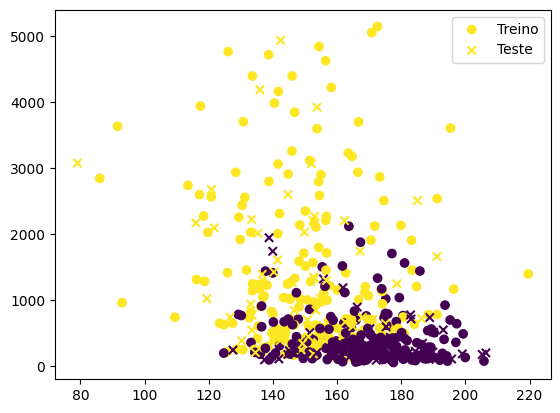

In [30]:
x_train = train_features
y_train = labels_train
x_test = test_features
y_test = labels_test
plt.scatter(x_train[:,0], x_train[:,1], c=y_train, label='Treino')
plt.scatter(x_test[:,0], x_test[:,1], c=y_test, marker='x', label='Teste')
plt.legend()
plt.show()

**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

Resposta:
1. Sim, o resultado é bOM para um modelo inicial. A acurácia de 81% no conjunto de teste indica que o modelo acerta a maioria das classificações. Além disso, as métricas de treino (acurácia de 82.5%) e teste (81%) estão muito próximas. Isso é um  sinal de que o modelo não está sofrendo de overfitting.

2. Alta capacidade de detecção (Recall): O modelo tem um Recall alto (88%). Isso significa que, quando a amostra pertence à classe positiva (geralmente a classe 1), o modelo é muito bom em encontrá-la, deixando passar poucos casos reais (apenas 6 Falsos Negativos no teste).Precisão mais baixa: A Precisão (77.1%) é consideravelmente menor que o Recall. Isso indica que, embora o modelo encontre a classe positiva facilmente, ele "chuta" essa classe com um pouco de excesso de confiança, acabando por classificar incorretamente várias amostras da classe negativa.

3. Analisando a Matriz de Confusão de teste [[37, 13], [6, 44]], fica claro que o erro mais frequente são os Falsos Positivos (o número 13 na matriz).
O modelo errou 13 vezes ao prever a classe positiva quando a resposta correta era a classe negativa (linha 0, coluna 1).


4. Garantir que os atributos estejam na mesma escala.

### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

In [ ]:
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte
def extract_features_resized(images):
    features = []
    for img in images:
        img_resized = resize(img, (14, 14), anti_aliasing=True)
        gray_float = rgb2gray(img_resized)
        gray = img_as_ubyte(gray_float)
        feat = histstat(gray)
        features.append(feat)
    return np.array(features)
train_features = extract_features_resized(images_train)
test_features = extract_features_resized(images_test)

# Entrenar con k=3 
model = KNeighborsClassifier(n_neighbors=3)
model.fit(train_features, labels_train)

# Evaluar
pred_test = model.predict(test_features)
pred_train = model.predict(train_features)

print("Métricas con imágenes redimensionadas y k=3:")
print("Acc test:", accuracy_score(labels_test, pred_test))
print("Prec test:", precision_score(labels_test, pred_test))
print("Recall test:", recall_score(labels_test, pred_test))
print("F1 test:", f1_score(labels_test, pred_test))

print("Acc train:", accuracy_score(labels_train, pred_train))
print("Prec train:", precision_score(labels_train, pred_train))
print("Recall train:", recall_score(labels_train, pred_train))
print("F1 train:", f1_score(labels_train, pred_train))

# Matriz de confusión
print("Matriz de confusión test:")
print(confusion_matrix(labels_test, pred_test))

Métricas con imágenes redimensionadas y k=3:
Acc test: 0.77
Prec test: 0.7647058823529411
Recall test: 0.78
F1 test: 0.7722772277227723
Acc train: 0.8725
Prec train: 0.8530805687203792
Recall train: 0.9
F1 train: 0.8759124087591241
Matriz de confusión test:
[[38 12]
 [11 39]]


## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.

In [51]:
def extract_features_rgb(images):
    features = []
    for img in images:
        img_resized = resize(img, (14, 14), anti_aliasing=True)
        h_r = np.histogram(img_resized[:, :, 0], bins=256)[0]
        h_g = np.histogram(img_resized[:, :, 1], bins=256)[0]
        h_b = np.histogram(img_resized[:, :, 2], bins=256)[0]
        f_r = histstat(h_r)
        f_g = histstat(h_g)
        f_b = histstat(h_b)
        features.append(np.concatenate([f_r, f_g, f_b], axis=0))
    return np.array(features)
train_features_rgb = extract_features_rgb(images_train)
test_features_rgb = extract_features_rgb(images_test)
print(f'train shape RGB: {train_features_rgb.shape}')
print(f'test shape RGB: {test_features_rgb.shape}')

# Entrenar modelo con atributos RGB
model_rgb = KNeighborsClassifier(n_neighbors=3)
model_rgb.fit(train_features_rgb, labels_train)

# Evaluar
pred_test_rgb = model_rgb.predict(test_features_rgb)
pred_train_rgb = model_rgb.predict(train_features_rgb)

print("Métricas con atributos RGB:")
print("Acc test:", accuracy_score(labels_test, pred_test_rgb))
print("Prec test:", precision_score(labels_test, pred_test_rgb))
print("Recall test:", recall_score(labels_test, pred_test_rgb))
print("F1 test:", f1_score(labels_test, pred_test_rgb))

print("Acc train:", accuracy_score(labels_train, pred_train_rgb))
print("Prec train:", precision_score(labels_train, pred_train_rgb))
print("Recall train:", recall_score(labels_train, pred_train_rgb))
print("F1 train:", f1_score(labels_train, pred_train_rgb))

# Matriz de confusión
print("Matriz de confusión test RGB:")
print(confusion_matrix(labels_test, pred_test_rgb))

train shape RGB: (400, 27)
test shape RGB: (100, 27)
Métricas con atributos RGB:
Acc test: 0.56
Prec test: 0.5535714285714286
Recall test: 0.62
F1 test: 0.5849056603773585
Acc train: 0.805
Prec train: 0.801980198019802
Recall train: 0.81
F1 train: 0.8059701492537313
Matriz de confusión test RGB:
[[25 25]
 [19 31]]


Neste exercício, a classificação foi repetida utilizando atributos extraídos diretamente dos histogramas das três bandas (RGB), resultando em 27 características por imagem (9 estatísticas por banda). Foram aplicadas as mesmas otimizações do exercício anterior, como o redimensionamento das imagens para 14x14 e o uso de k=3 no classificador KNN. No entanto, os resultados foram consideravelmente piores do que os obtidos com imagens em tons de cinza (acurácia de 0.56 contra ~0.77).

## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

In [ ]:
from skimage.feature import graycomatrix, graycoprops  # 'grey' fue cambiado a 'gray'
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def extract_glcm_features(img, distances=[1], angles=[0], levels=8):
    gray = img_as_ubyte(rgb2gray(img))
    gray_q = (gray // (256 // levels)).astype(np.uint8)
    glcm = graycomatrix(gray_q, distances=distances, angles=angles, levels=levels, symmetric=True, normed=True)
    feats = []
    for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]:
        feats.append(graycoprops(glcm, prop).mean())
    
    return np.array(feats)

def extract_texture_features(images):
    return np.vstack([extract_glcm_features(img) for img in images])
train_tex = extract_texture_features(images_train)
test_tex = extract_texture_features(images_test)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(train_tex, labels_train)

pred_test = model.predict(test_tex)

print("Acc test:", accuracy_score(labels_test, pred_test))


print("Prec test:", precision_score(labels_test, pred_test, average='weighted', zero_division=0))
print("Recall test:", recall_score(labels_test, pred_test, average='weighted', zero_division=0))
print("F1 test:", f1_score(labels_test, pred_test, average='weighted', zero_division=0))

Acc test: 0.76
Prec test: 0.7637987012987013
Recall test: 0.76
F1 test: 0.7591328783621036
